In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
base_dir = Path.cwd()

# Lettura file Parquet
df = pd.read_parquet(base_dir / 'synthetic_data_sdv.parquet')

# Salvataggio come CSV in data
df.to_csv(base_dir / 'synt_data.csv', index=False)

In [3]:
file = base_dir / 'synt_data.csv'
df = pd.read_csv(file, sep=',')
df.head(5)

,timestamp,Machine_ID,Cycle_Phase_ID,Current_L1,Current_L2,Current_L3,Voltage_L_L,Active_Power,Reactive_Power,Power_Factor,THD_Current,Current_Peak_to_Peak,Inrush_Current_Peak,Phase_Imbalance_Ratio,Energy_per_Cycle,Power_Variance_10s,Inrush_Duration,THD_Voltage,Is_Anomaly,Anomaly_Type
0,1970-01-21 11:32:06,WM_01,3,22.3,21.2,20.4,400.3,12518.7,420.2,0.96,2.6,31.6,70.2,0.5,3.0,383.5,1.6,0.9,0,NaN
1,1970-01-21 11:32:06,WM_03,3,5.2,9.0,16.2,399.1,2912.8,420.2,0.96,2.1,7.4,15.4,2.2,2.7,54.4,2.2,0.9,0,NaN
2,1970-01-21 11:32:06,WM_03,2,14.7,8.9,7.3,399.4,6878.6,420.2,0.96,2.5,21.5,46.4,4.0,1.8,326.2,1.2,0.9,0,NaN
3,1970-01-21 11:32:06,WM_05,3,6.1,16.4,8.8,400.5,4035.9,420.2,0.96,1.8,8.6,18.6,0.6,3.2,58.8,1.3,0.9,0,NaN
4,1970-01-21 11:32:06,WM_03,4,34.6,19.9,21.5,400.4,20489.5,420.2,0.94,2.8,49.2,112.7,0.5,3.0,600.1,0.5,0.9,0,NaN


In [4]:
df.tail(5)

,timestamp,Machine_ID,Cycle_Phase_ID,Current_L1,Current_L2,Current_L3,Voltage_L_L,Active_Power,Reactive_Power,Power_Factor,THD_Current,Current_Peak_to_Peak,Inrush_Current_Peak,Phase_Imbalance_Ratio,Energy_per_Cycle,Power_Variance_10s,Inrush_Duration,THD_Voltage,Is_Anomaly,Anomaly_Type
99995,1970-01-21 11:32:06,WM_01,4,4.5,8.4,10.9,399.9,2659.1,420.2,0.96,1.4,6.1,12.2,0.6,2.2,67.4,1.6,0.9,0,NaN
99996,1970-01-21 11:32:06,WM_02,3,36.1,19.6,18.7,400.3,19512.4,420.2,0.94,4.2,52.0,115.4,0.7,2.3,774.0,0.2,0.9,0,NaN
99997,1970-01-21 11:32:06,WM_01,4,21.1,18.7,16.6,400.2,11546.4,420.2,0.94,2.8,30.5,69.2,1.1,2.8,301.7,0.3,0.9,0,NaN
99998,1970-01-21 11:32:06,WM_02,2,7.4,5.7,7.5,400.4,4054.6,420.2,0.96,1.8,10.6,23.0,1.9,2.8,94.1,0.6,0.9,0,NaN
99999,1970-01-21 11:32:06,WM_03,1,5.5,16.5,9.9,400.5,3356.8,420.2,0.96,1.5,7.9,16.8,0.9,2.6,72.4,1.5,0.9,0,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   timestamp              100000 non-null  str    
 1   Machine_ID             100000 non-null  str    
 2   Cycle_Phase_ID         100000 non-null  int64  
 3   Current_L1             100000 non-null  float64
 4   Current_L2             100000 non-null  float64
 5   Current_L3             100000 non-null  float64
 6   Voltage_L_L            100000 non-null  float64
 7   Active_Power           100000 non-null  float64
 8   Reactive_Power         100000 non-null  float64
 9   Power_Factor           100000 non-null  float64
 10  THD_Current            100000 non-null  float64
 11  Current_Peak_to_Peak   100000 non-null  float64
 12  Inrush_Current_Peak    100000 non-null  float64
 13  Phase_Imbalance_Ratio  100000 non-null  float64
 14  Energy_per_Cycle       100000 non-null  float64


In [6]:
# Trasformo i valori di Timestamp da str --> datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
df.describe()

,timestamp,Cycle_Phase_ID,Current_L1,Current_L2,Current_L3,Voltage_L_L,Active_Power,Reactive_Power,Power_Factor,THD_Current,Current_Peak_to_Peak,Inrush_Current_Peak,Phase_Imbalance_Ratio,Energy_per_Cycle,Power_Variance_10s,Inrush_Duration,THD_Voltage,Is_Anomaly
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1970-01-21 11:32:06,2.677240,12.855038,12.813798,12.581059,399.987414,7381.772512,4.202000e+02,0.947935,2.247706,18.125694,40.246901,1.450062,2.410737,193.155070,1.596706,0.904743,0.063350
min,1970-01-21 11:32:06,1.000000,2.200000,2.100000,2.300000,394.600000,1450.500000,4.202000e+02,0.650000,1.100000,3.200000,6.100000,0.500000,0.600000,45.500000,0.200000,0.900000,0.000000
25%,1970-01-21 11:32:06,2.000000,5.300000,8.000000,7.200000,399.800000,3069.175000,4.202000e+02,0.940000,1.600000,7.300000,15.200000,0.500000,2.000000,63.000000,0.500000,0.900000,0.000000
50%,1970-01-21 11:32:06,3.000000,9.700000,13.400000,13.000000,400.200000,5554.350000,4.202000e+02,0.960000,2.000000,13.500000,29.500000,0.800000,2.600000,117.600000,1.200000,0.900000,0.000000
75%,1970-01-21 11:32:06,4.000000,17.100000,18.000000,18.200000,400.400000,9835.800000,4.202000e+02,0.960000,2.700000,24.100000,54.400000,1.700000,2.900000,245.200000,2.300000,0.900000,0.000000
max,1970-01-21 11:32:06,4.000000,108.000000,21.600000,22.100000,400.500000,45500.200000,4.202000e+02,0.960000,11.400000,153.900000,330.700000,22.900000,3.200000,2157.600000,8.100000,2.200000,1.000000
std,NaN,1.045972,10.473749,5.849979,6.245342,0.528194,5867.544037,5.684370e-14,0.021577,0.918772,14.941030,34.289484,1.554040,0.632321,197.980272,1.375061,0.033218,0.243593


In [8]:
df['Machine_ID'].value_counts().sort_index()

Machine_ID
WM_01    20668
WM_02    19665
WM_03    19361
WM_04    19598
WM_05    20708
Name: count, dtype: int64

In [9]:
df['Cycle_Phase_ID'].value_counts().sort_index()

Cycle_Phase_ID
1    15554
2    29387
3    26840
4    28219
Name: count, dtype: int64

In [10]:
df['Anomaly_Type'].unique()

<ArrowStringArray>
[nan, 'Collective', 'Contextual', 'Point']
Length: 4, dtype: str

In [11]:
df['Anomaly_Type'].value_counts()

Anomaly_Type
Collective    4906
Contextual     931
Point          901
Name: count, dtype: int64

In [12]:
print(df[df['Cycle_Phase_ID'] == 1])


                timestamp Machine_ID  Cycle_Phase_ID  Current_L1  Current_L2  \
5     1970-01-21 11:32:06      WM_02               1         2.9         7.4   
16    1970-01-21 11:32:06      WM_04               1         4.6        11.2   
22    1970-01-21 11:32:06      WM_05               1         2.8         2.1   
23    1970-01-21 11:32:06      WM_04               1         2.2         2.1   
25    1970-01-21 11:32:06      WM_01               1        32.3        15.9   
...                   ...        ...             ...         ...         ...   
99968 1970-01-21 11:32:06      WM_04               1         2.4         2.1   
99971 1970-01-21 11:32:06      WM_03               1         2.6         3.3   
99979 1970-01-21 11:32:06      WM_04               1         4.4         4.5   
99994 1970-01-21 11:32:06      WM_02               1         2.9         2.1   
99999 1970-01-21 11:32:06      WM_03               1         5.5        16.5   

       Current_L3  Voltage_L_L  Active_

In [13]:
# Verifica la distribuzione delle fasi
print("Distribuzione Cycle_Phase_ID:")
print(df['Cycle_Phase_ID'].value_counts().sort_index())

# Verifica se ci sono valori nulli
print(f"\nValori nulli in Cycle_Phase_ID: {df['Cycle_Phase_ID'].isna().sum()}")

# Guarda i primi dati della fase 1
print("\nDati Cycle_Phase_ID == 1:")
print(df[df['Cycle_Phase_ID'] == 1][['timestamp', 'Current_L1', 'Current_L2', 'Current_L3']])

# Verifica il range temporale totale
print(f"\nRange temporale totale:")
print(f"Inizio: {df['timestamp'].min()}")
print(f"Fine: {df['timestamp'].max()}")

Distribuzione Cycle_Phase_ID:
Cycle_Phase_ID
1    15554
2    29387
3    26840
4    28219
Name: count, dtype: int64

Valori nulli in Cycle_Phase_ID: 0

Dati Cycle_Phase_ID == 1:
                timestamp  Current_L1  Current_L2  Current_L3
5     1970-01-21 11:32:06         2.9         7.4         4.1
16    1970-01-21 11:32:06         4.6        11.2         4.2
22    1970-01-21 11:32:06         2.8         2.1         2.3
23    1970-01-21 11:32:06         2.2         2.1         2.3
25    1970-01-21 11:32:06        32.3        15.9        12.3
...                   ...         ...         ...         ...
99968 1970-01-21 11:32:06         2.4         2.1         2.3
99971 1970-01-21 11:32:06         2.6         3.3         2.3
99979 1970-01-21 11:32:06         4.4         4.5         7.5
99994 1970-01-21 11:32:06         2.9         2.1         2.3
99999 1970-01-21 11:32:06         5.5        16.5         9.9

[15554 rows x 4 columns]

Range temporale totale:
Inizio: 1970-01-21 11:32:06


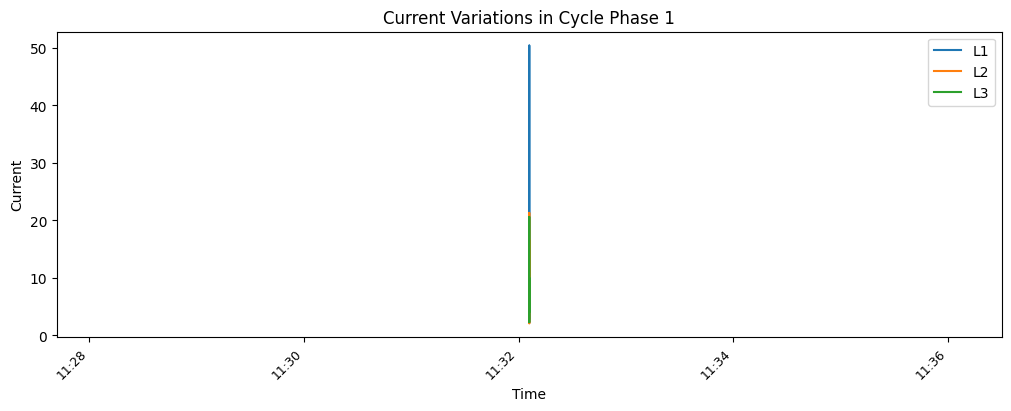

In [14]:
# Current in Cycle Phase 1
Current_L1 = df.loc[df['Cycle_Phase_ID'] == 1, 'Current_L1']
Current_L2 = df.loc[df['Cycle_Phase_ID'] == 1, 'Current_L2']
Current_L3 = df.loc[df['Cycle_Phase_ID'] == 1, 'Current_L3']
timestamp = df.loc[df['Cycle_Phase_ID'] == 1, 'timestamp']

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(timestamp, Current_L1, label='L1')
plt.plot(timestamp, Current_L2, label='L2')
plt.plot(timestamp, Current_L3, label='L3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("Current Variations in Cycle Phase 1")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

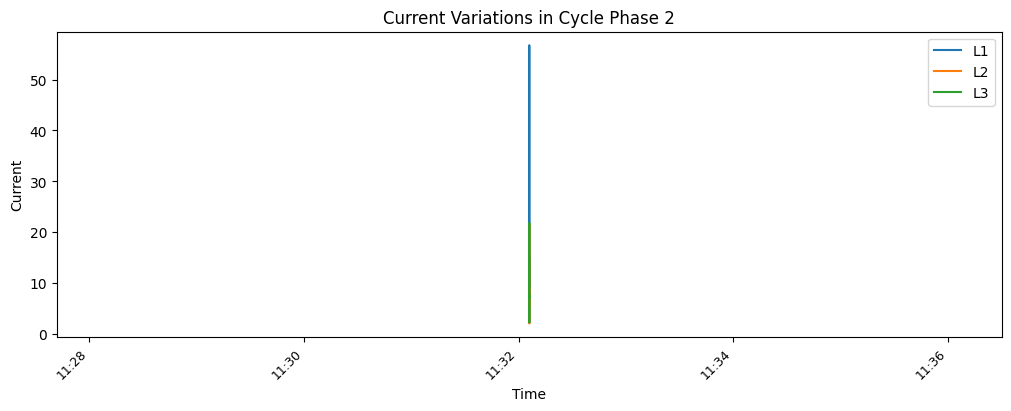

In [15]:
# Current in Cycle Phase 2

Current_L1 = df.loc[df['Cycle_Phase_ID'] == 2, 'Current_L1']
Current_L2 = df.loc[df['Cycle_Phase_ID'] == 2, 'Current_L2']
Current_L3 = df.loc[df['Cycle_Phase_ID'] == 2, 'Current_L3']
timestamp = df.loc[df['Cycle_Phase_ID'] == 2, 'timestamp']

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(timestamp, Current_L1, label='L1')
plt.plot(timestamp, Current_L2, label='L2')
plt.plot(timestamp, Current_L3, label='L3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("Current Variations in Cycle Phase 2")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

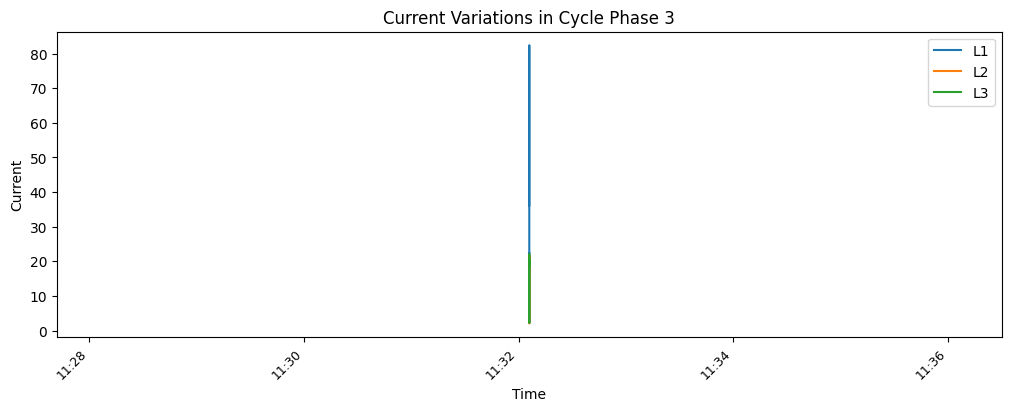

In [16]:
# Current in Cycle Phase 3

Current_L1 = df.loc[df['Cycle_Phase_ID'] == 3, 'Current_L1']
Current_L2 = df.loc[df['Cycle_Phase_ID'] == 3, 'Current_L2']
Current_L3 = df.loc[df['Cycle_Phase_ID'] == 3, 'Current_L3']
timestamp = df.loc[df['Cycle_Phase_ID'] == 3, 'timestamp']

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(timestamp, Current_L1, label='L1')
plt.plot(timestamp, Current_L2, label='L2')
plt.plot(timestamp, Current_L3, label='L3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("Current Variations in Cycle Phase 3")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

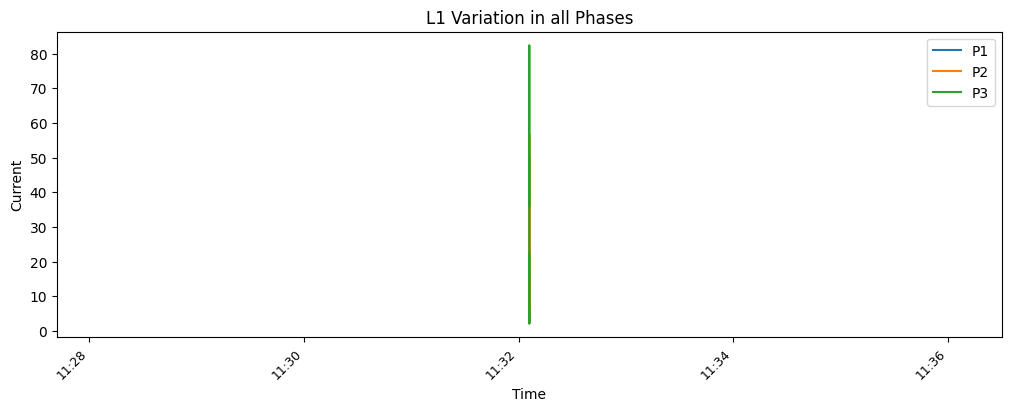

In [17]:
# L1 Variation in all Phases

# Filtra i dati per ogni fase (includendo anche il timestamp)
Phase1 = df.loc[df['Cycle_Phase_ID'] == 1, ['timestamp', 'Current_L1']]
Phase2 = df.loc[df['Cycle_Phase_ID'] == 2, ['timestamp', 'Current_L1']]
Phase3 = df.loc[df['Cycle_Phase_ID'] == 3, ['timestamp', 'Current_L1']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(Phase1['timestamp'], Phase1['Current_L1'], label='P1')
plt.plot(Phase2['timestamp'], Phase2['Current_L1'], label='P2')
plt.plot(Phase3['timestamp'], Phase3['Current_L1'], label='P3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L1 Variation in all Phases")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

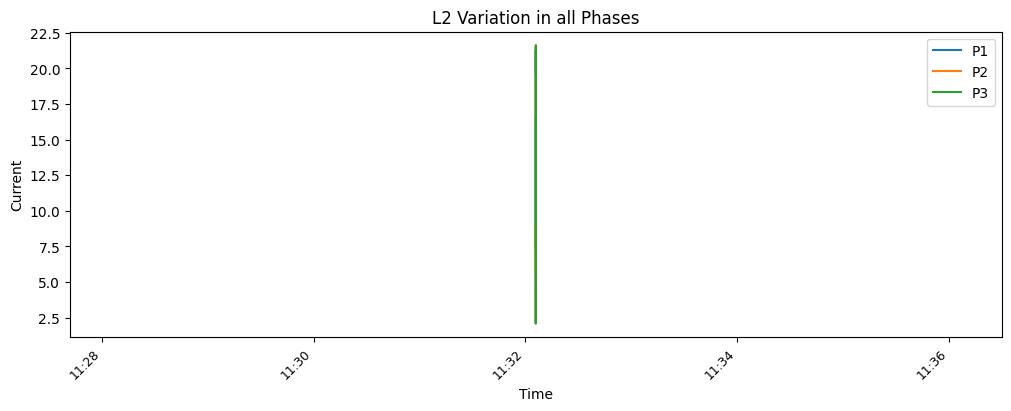

In [18]:
# L2 Variation in all Phases

# Filtra i dati per ogni fase (includendo anche il timestamp)
Phase1 = df.loc[df['Cycle_Phase_ID'] == 1, ['timestamp', 'Current_L2']]
Phase2 = df.loc[df['Cycle_Phase_ID'] == 2, ['timestamp', 'Current_L2']]
Phase3 = df.loc[df['Cycle_Phase_ID'] == 3, ['timestamp', 'Current_L2']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(Phase1['timestamp'], Phase1['Current_L2'], label='P1')
plt.plot(Phase2['timestamp'], Phase2['Current_L2'], label='P2')
plt.plot(Phase3['timestamp'], Phase3['Current_L2'], label='P3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L2 Variation in all Phases")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

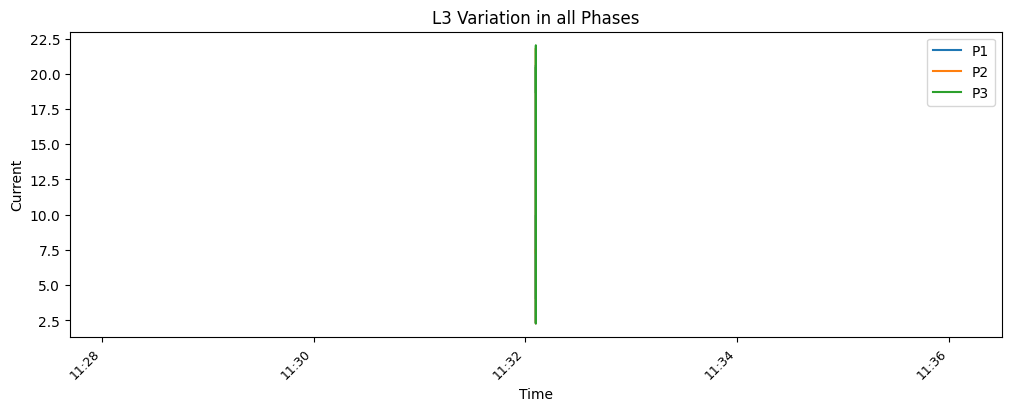

In [19]:
# L3 Variation in all Phases

# Filtra i dati per ogni fase (includendo anche il timestamp)
Phase1 = df.loc[df['Cycle_Phase_ID'] == 1, ['timestamp', 'Current_L3']]
Phase2 = df.loc[df['Cycle_Phase_ID'] == 2, ['timestamp', 'Current_L3']]
Phase3 = df.loc[df['Cycle_Phase_ID'] == 3, ['timestamp', 'Current_L3']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(Phase1['timestamp'], Phase1['Current_L3'], label='P1')
plt.plot(Phase2['timestamp'], Phase2['Current_L3'], label='P2')
plt.plot(Phase3['timestamp'], Phase3['Current_L3'], label='P3')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L3 Variation in all Phases")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

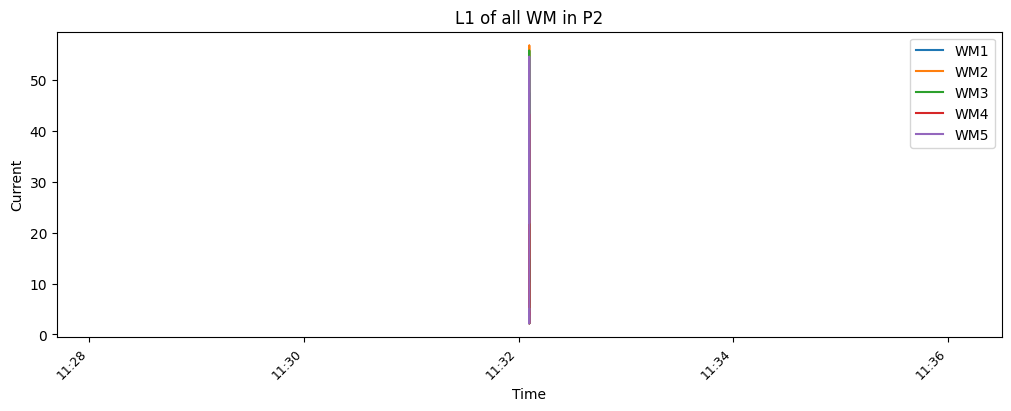

In [20]:
# Dai grafici si evince che l'anomalia risiede nella Phase 2
# Procedo ad analizzare la Phase 2 più nel dettaglio

# L1 Variation of all Machines in P2

# Filtra i dati per ogni fase (includendo anche il timestamp)
WM1 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_01'), ['timestamp', 'Current_L1']]
WM2 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_02'), ['timestamp', 'Current_L1']]
WM3 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_03'), ['timestamp', 'Current_L1']]
WM4 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_04'), ['timestamp', 'Current_L1']]
WM5 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_05'), ['timestamp', 'Current_L1']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(WM1['timestamp'], WM1['Current_L1'], label='WM1')
plt.plot(WM2['timestamp'], WM2['Current_L1'], label='WM2')
plt.plot(WM3['timestamp'], WM3['Current_L1'], label='WM3')
plt.plot(WM4['timestamp'], WM4['Current_L1'], label='WM4')
plt.plot(WM5['timestamp'], WM5['Current_L1'], label='WM5')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L1 of all WM in P2")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

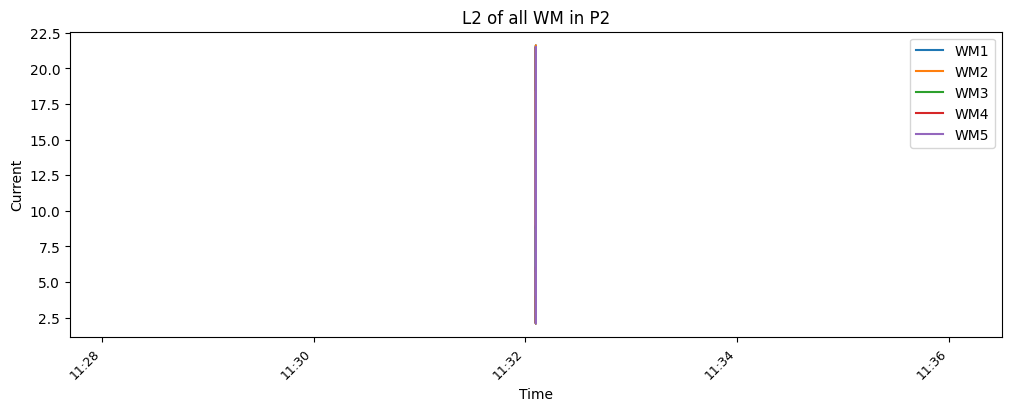

In [21]:
# L2 Variation of all Machines in P2

# Filtra i dati per ogni fase (includendo anche il timestamp)
WM1 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_01'), ['timestamp', 'Current_L2']]
WM2 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_02'), ['timestamp', 'Current_L2']]
WM3 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_03'), ['timestamp', 'Current_L2']]
WM4 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_04'), ['timestamp', 'Current_L2']]
WM5 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_05'), ['timestamp', 'Current_L2']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(WM1['timestamp'], WM1['Current_L2'], label='WM1')
plt.plot(WM2['timestamp'], WM2['Current_L2'], label='WM2')
plt.plot(WM3['timestamp'], WM3['Current_L2'], label='WM3')
plt.plot(WM4['timestamp'], WM4['Current_L2'], label='WM4')
plt.plot(WM5['timestamp'], WM5['Current_L2'], label='WM5')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L2 of all WM in P2")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

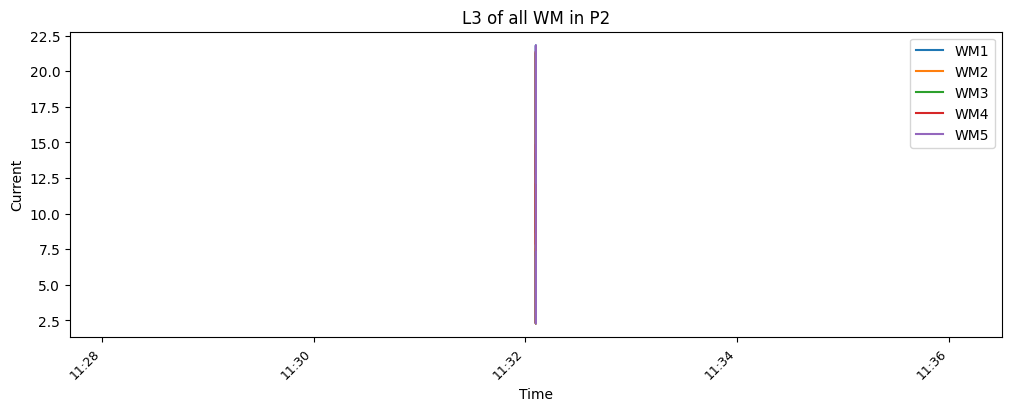

In [22]:
# L3 Variation of all Machines in P2

# Filtra i dati per ogni fase (includendo anche il timestamp)
WM1 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_01'), ['timestamp', 'Current_L3']]
WM2 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_02'), ['timestamp', 'Current_L3']]
WM3 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_03'), ['timestamp', 'Current_L3']]
WM4 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_04'), ['timestamp', 'Current_L3']]
WM5 = df.loc[(df['Cycle_Phase_ID'] == 2) & (df['Machine_ID'] == 'WM_05'), ['timestamp', 'Current_L3']]

plt.figure(figsize=(10, 4), layout='constrained')
plt.plot(WM1['timestamp'], WM1['Current_L3'], label='WM1')
plt.plot(WM2['timestamp'], WM2['Current_L3'], label='WM2')
plt.plot(WM3['timestamp'], WM3['Current_L3'], label='WM3')
plt.plot(WM4['timestamp'], WM4['Current_L3'], label='WM4')
plt.plot(WM5['timestamp'], WM5['Current_L3'], label='WM5')
plt.xlabel('Time')
plt.ylabel('Current')
plt.title("L3 of all WM in P2")
plt.legend()

# Formattazione asse x
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # mostra solo ore:minuti
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))  # etichetta ogni 2 minuti

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.show()

In [23]:
# Dai grafici si evince che l'anomalia 'On Point' riguarda la WM_01